## The Best Strategy for your RTX 3050
Since your RTX 3050 has limited VRAM (likely 4GB or 8GB), you don't want to waste memory on completely empty files if a song has a long silence at the beginning or end.

The "Master Stem" Approach:

Pick the Other stem as your "Master" (since it usually has the most melodic content).

Check the volume of the Other chunk.

If Other is above your threshold, save ALL FOUR stems for that timestamp.

If Other is below the threshold (total silence), discard ALL FOUR.

This keeps your data synchronized while still cleaning out the "dead air" at the start and end of tracks.

#### Preprocessing the data of four stem (vocals, drums, other and bass ) on same timestamps because
#### The Multi input mini cnn requires vocal, drum, other and bass chunk with same label and equal input



In [17]:
import os
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.image import resize

In [5]:
def load_multi_input_data(data_dir, classes, sample_set_rate, target_shape=(150, 150), threshold=0.01):
    # Lists for each stem
    v_data, d_data, b_data, o_data = [], [], [], [] ##will store all the spectrogram data
    labels = [] # will store the labels data

    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print(f"--- Processing Genre: {class_name} ---")

        # Get list of folders and filter out non-directories
        song_folders = [f for f in os.listdir(class_dir) if os.path.isdir(os.path.join(class_dir, f))]

        for index, song_folder_name in enumerate(song_folders):
            song_folder_path = os.path.join(class_dir, song_folder_name)
            print(f"[{index+1}/{len(song_folders)}] Processing: {song_folder_name}", end='\r')

            if not os.path.isdir(song_folder_path):
                continue

            try:
                # 1. LOAD ALL 4 STEMS SIMULTANEOUSLY
                # We use fixed sr to ensure they all have the same length
                v_audio, _ = librosa.load(os.path.join(song_folder_path, 'vocals.wav'), sr=sample_set_rate)
                d_audio, _ = librosa.load(os.path.join(song_folder_path, 'drums.wav'), sr=sample_set_rate)
                b_audio, _ = librosa.load(os.path.join(song_folder_path, 'bass.wav'), sr=sample_set_rate)
                o_audio, _ = librosa.load(os.path.join(song_folder_path, 'other.wav'), sr=sample_set_rate)
                
                sample_rate = sample_set_rate #function sample rate, common for all
            except Exception as e:
                print(f"Skipping {song_folder_name} due to missing/corrupt stems: {e}")
                continue

            # 2. SLIDING WINDOW SETUP
            chunk_duration = 4
            overlap_duration = 2
            chunk_samples = int(chunk_duration * sample_rate)
            stride = int((chunk_duration - overlap_duration) * sample_rate)

            # 3. SYNCHRONIZED CLIPPING
            # We loop based on the length of the audio
            for start in range(0, len(o_audio) - chunk_samples + 1, stride):
                end = start + chunk_samples
                
                # Extract chunks from ALL stems using the SAME start/end
                v_chunk = v_audio[start:end]
                d_chunk = d_audio[start:end]
                b_chunk = b_audio[start:end]
                o_chunk = o_audio[start:end]

                # 4. MASTER THRESHOLD CHECK (Based on 'Other' stem)
                rms_other = np.sqrt(np.mean(o_chunk**2))
                
                if rms_other > threshold:
                    # Process each chunk into a Mel-Spectrogram
                    for chunk, target_list in zip([v_chunk, d_chunk, b_chunk, o_chunk], #v_chunk is a chunk not list
                                                 [v_data, d_data, b_data, o_data]): #but v_data is list where we append v_chunk
                        
                        mel = librosa.feature.melspectrogram(y=chunk, sr=sample_rate, n_mels=150)
                        mel_db = librosa.power_to_db(mel, ref=np.max)
                        
                        # Resize and convert to NumPy
                        mel_resized = resize(np.expand_dims(mel_db, axis=-1), target_shape).numpy()
                        target_list.append(mel_resized)
                    
                    labels.append(i_class)
            # MEMORY CLEANUP: Clear large audio arrays from memory
            del v_audio, d_audio, b_audio, o_audio

    # Return as 5 separate NumPy arrays
    return (np.array(v_data), np.array(d_data), np.array(b_data), 
            np.array(o_data), np.array(labels))


In [6]:
data_dir = '.\hindi_stems' 
classes = ['bollypop', 'carnatic', 'ghazal', 'semiclassical', 'sufi']

In [ ]:
# --- EXECUTION ---
vocal_mel, drums_mel, base_mel, other_mel, labels = load_multi_input_data(data_dir, classes, 22050)

#on the same timestamps with labels but in order (first bollypop then carnatic then gazal then semiclassial at last sufi)

--- Processing Genre: bollypop ---


c:\Users\Suraj\Desktop\Projects\Indian_Music_Genre_Classifier\hindi_music\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Processing Genre: carnatic ---
--- Processing Genre: ghazal ---
--- Processing Genre: semiclassical ---
--- Processing Genre: sufi ---


In [ ]:
# 13m 14.8 second

In [8]:
# c:\Users\Suraj\Desktop\Projects\Indian_Music_Genre_Classifier\hindi_music\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
#   from .autonotebook import tqdm as notebook_tqdm
# --- Processing Genre: carnatic ---
# --- Processing Genre: ghazal ---
# [23/100] Processing: gz220

In [9]:
# 2. Save to a single compressed file
print("Saving processed data...")
np.savez_compressed(
    'indian_genre_multi_input_data.npz', 
    vocal=vocal_mel, 
    drums=drums_mel, 
    bass=base_mel, 
    other=other_mel,
    labels=labels
)
print("Done! You can now load this instantly next time.")

Saving processed data...
Done! You can now load this instantly next time.


In [10]:
# Load the bundle
data = np.load('indian_genre_multi_input_data.npz')

# Extract the arrays
X_vocal = data['vocal']
X_drums = data['drums']
X_bass  = data['bass']
X_other = data['other']
y       = data['labels']

print(f"Dataset loaded: {X_vocal.shape[0]} aligned samples ready for training.")

Dataset loaded: 10198 aligned samples ready for training.


In [15]:
print(f'Shape Vocal: {X_vocal.shape}')
print(f'Shape: Drums {X_drums.shape}')
print(f'Shape: Bass {X_bass.shape}')
print(f'Shape: Other {X_other.shape}')
print(f'labels : {y.shape}')
print(f'Unique label: {np.unique(labels)}')

Shape Vocal: (10198, 150, 150, 1)
Shape: Drums (10198, 150, 150, 1)
Shape: Bass (10198, 150, 150, 1)
Shape: Other (10198, 150, 150, 1)
labels : (10198,)
Unique label: [0 1 2 3 4]


In [16]:
# This is perfect. You have achieved Temporal Alignment for all 10,198 samples. This means your data is now in the ideal format
#  for a Multi-Input CNN to learn the complex relationships between Indian instruments.

# Because you have 5 unique labels ([0 1 2 3 4]), your model will be a Multi-Class Classifier rather than just a binary one.
#  Here is exactly how to feed this into your RTX 3050 for training.

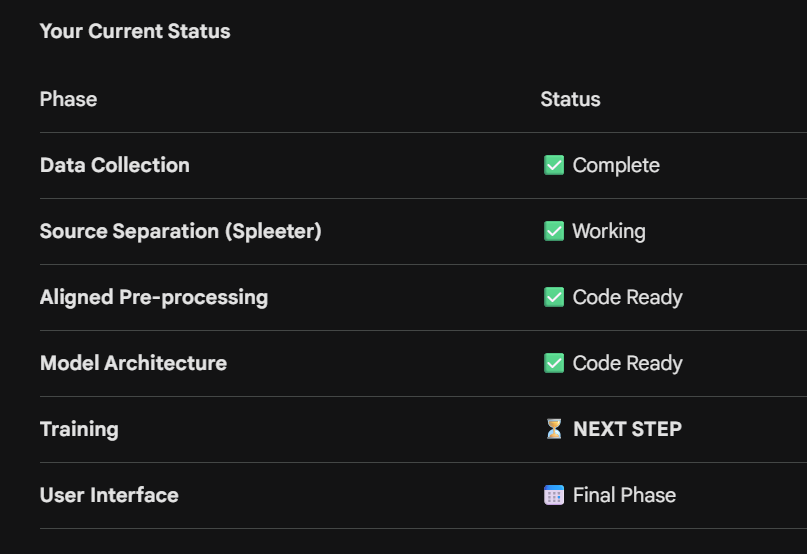

This is perfect. You have achieved Temporal Alignment for all 10,198 samples. This means your data is now in the ideal format for a Multi-Input CNN to learn the complex relationships between Indian instruments.

Because you have 5 unique labels ([0 1 2 3 4]), your model will be a Multi-Class Classifier rather than just a binary one. Here is exactly how to feed this into your RTX 3050 for training.m
